# Notebook 2 — Clusterização de embeddings para detecção de fraude

Objetivos:

- transformar transações estruturadas em narrativas textuais
- gerar embeddings dessas narrativas
- clusterizar os comportamentos
- identificar clusters com maior concentração de fraude

O dataset é sintético, mas a lógica é real: embeddings ajudam a agrupar comportamento parecido mesmo quando o texto não é idêntico.


In [21]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)

cwd = Path.cwd()
candidates = [
    cwd,
    cwd.parent,
    cwd / "aulao-3-embeddings-e-vector-db",
    cwd.parent / "aulao-3-embeddings-e-vector-db",
]
if cwd.name == "notebooks":
    candidates.insert(0, cwd.parent)
PROJECT_ROOT = next(
    (
        path
        for path in candidates
        if (path / ".env").exists() or (path / "data" / "rag_docs").exists()
    ),
    cwd.parent if cwd.name == "notebooks" else cwd,
)
load_dotenv(PROJECT_ROOT / ".env", override=True)


True

In [22]:
rng = np.random.default_rng(42)


def sample(records, n, fraud_label):
    rows = []
    for idx in range(n):
        template = records[rng.integers(0, len(records))]
        value = round(float(rng.uniform(*template["value_range"])), 2)
        hour = int(rng.choice(template["hours"]))
        city = str(rng.choice(template["cities"]))
        country = str(rng.choice(template["countries"]))
        rows.append(
            {
                "tx_id": f"tx_{fraud_label}_{idx:04d}",
                "perfil_simulado": template["profile"],
                "merchant": str(rng.choice(template["merchants"])),
                "descricao": str(rng.choice(template["descriptions"])),
                "canal": template["channel"],
                "cartao_presente": template["card_present"],
                "risco_device": template["device_risk"],
                "pais": country,
                "cidade": city,
                "hora": hour,
                "valor": value,
                "fraude": fraud_label,
            }
        )
    return rows


legit_templates = [
    {
        "profile": "supermercado_rotina",
        "merchants": ["Mercado Bom Dia", "Super Vale", "Atacado Centro"],
        "descriptions": [
            "compra presencial de supermercado",
            "itens de mercado e higiene",
            "carrinho semanal da família",
        ],
        "channel": "presencial",
        "card_present": "sim",
        "device_risk": "baixo",
        "countries": ["BR"],
        "cities": ["São Paulo", "Campinas", "Osasco"],
        "hours": [9, 10, 11, 17, 18, 19],
        "value_range": (75, 420),
    },
    {
        "profile": "farmacia_recorrente",
        "merchants": ["Farmácia Central", "Drogaria Vida", "Saúde Já"],
        "descriptions": [
            "compra de medicamentos e higiene",
            "farmácia de bairro",
            "remédios e itens pessoais",
        ],
        "channel": "presencial",
        "card_present": "sim",
        "device_risk": "baixo",
        "countries": ["BR"],
        "cities": ["São Paulo", "Santos", "Santo André"],
        "hours": [8, 9, 12, 18, 19, 20],
        "value_range": (25, 180),
    },
    {
        "profile": "combustivel_trajeto",
        "merchants": ["Auto Posto Norte", "Rede Rota", "Posto Avenida"],
        "descriptions": [
            "abastecimento do veículo",
            "posto de gasolina na rota",
            "combustível e conveniência",
        ],
        "channel": "presencial",
        "card_present": "sim",
        "device_risk": "baixo",
        "countries": ["BR"],
        "cities": ["São Paulo", "Guarulhos", "Barueri"],
        "hours": [7, 8, 18, 19, 20],
        "value_range": (120, 350),
    },
    {
        "profile": "assinatura_digital",
        "merchants": ["StreamFlix", "Music Plus", "Cloud Drive"],
        "descriptions": [
            "renovação de assinatura mensal",
            "serviço digital recorrente",
            "plano online renovado automaticamente",
        ],
        "channel": "ecommerce",
        "card_present": "não",
        "device_risk": "baixo",
        "countries": ["BR"],
        "cities": ["São Paulo", "Curitiba", "Recife"],
        "hours": [6, 7, 8, 12],
        "value_range": (19, 89),
    },
]


fraud_templates = [
    {
        "profile": "gift_card_madrugada",
        "merchants": ["GiftFast", "CardNow", "Voucher Global"],
        "descriptions": [
            "compra digital de gift card internacional",
            "voucher eletrônico entregue por e-mail",
            "gift card online em valor alto",
        ],
        "channel": "ecommerce",
        "card_present": "não",
        "device_risk": "alto",
        "countries": ["US", "GB"],
        "cities": ["Miami", "Londres"],
        "hours": [0, 1, 2, 3, 4],
        "value_range": (450, 980),
    },
    {
        "profile": "micro_teste_cartao",
        "merchants": ["PayLink Test", "Checkout Edge", "Gateway Trial"],
        "descriptions": [
            "microtransação para validação de cartão",
            "teste de cartão em comércio online",
            "sequência de compra pequena em gateway",
        ],
        "channel": "ecommerce",
        "card_present": "não",
        "device_risk": "alto",
        "countries": ["GB", "NL", "US"],
        "cities": ["Londres", "Amsterdã", "Miami"],
        "hours": [1, 2, 3, 4],
        "value_range": (2, 22),
    },
    {
        "profile": "eletronico_internacional",
        "merchants": ["Mega Electro", "Tech World", "Premium Devices"],
        "descriptions": [
            "eletrônico premium com entrega expressa",
            "compra internacional de alto valor",
            "tablet e acessórios em loja estrangeira",
        ],
        "channel": "ecommerce",
        "card_present": "não",
        "device_risk": "alto",
        "countries": ["US", "AE"],
        "cities": ["Miami", "Dubai"],
        "hours": [0, 1, 2, 22, 23],
        "value_range": (1800, 4200),
    },
]


rows = []
rows.extend(sample(legit_templates, n=340, fraud_label=0))
rows.extend(sample(fraud_templates, n=70, fraud_label=1))
df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

df["narrativa"] = (
    "transação "
    + df["canal"]
    + " no merchant "
    + df["merchant"]
    + "; descrição "
    + df["descricao"]
    + "; perfil "
    + df["perfil_simulado"]
    + "; valor R$ "
    + df["valor"].round(2).astype(str)
    + "; hora "
    + df["hora"].astype(str).str.zfill(2)
    + ":15; país "
    + df["pais"]
    + "; cidade "
    + df["cidade"]
    + "; cartão_presente "
    + df["cartao_presente"]
    + "; risco_device "
    + df["risco_device"]
)

df.head(5)


,tx_id,perfil_simulado,merchant,descricao,canal,cartao_presente,risco_device,pais,cidade,hora,valor,fraude,narrativa
0,tx_0_0172,combustivel_trajeto,Posto Avenida,posto de gasolina na rota,presencial,sim,baixo,BR,São Paulo,20,285.76,0,transação presencial no merchant Posto Avenida; descrição posto de gasolina na rota; perfil combustivel_trajeto; valor R$ 285.76; hora 2...
1,tx_0_0137,farmacia_recorrente,Saúde Já,farmácia de bairro,presencial,sim,baixo,BR,São Paulo,20,88.36,0,transação presencial no merchant Saúde Já; descrição farmácia de bairro; perfil farmacia_recorrente; valor R$ 88.36; hora 20:15; país BR...
2,tx_0_0126,farmacia_recorrente,Farmácia Central,compra de medicamentos e higiene,presencial,sim,baixo,BR,São Paulo,8,138.87,0,transação presencial no merchant Farmácia Central; descrição compra de medicamentos e higiene; perfil farmacia_recorrente; valor R$ 138....
3,tx_0_0094,supermercado_rotina,Mercado Bom Dia,itens de mercado e higiene,presencial,sim,baixo,BR,São Paulo,10,328.54,0,transação presencial no merchant Mercado Bom Dia; descrição itens de mercado e higiene; perfil supermercado_rotina; valor R$ 328.54; hor...
4,tx_0_0072,farmacia_recorrente,Farmácia Central,remédios e itens pessoais,presencial,sim,baixo,BR,São Paulo,12,63.42,0,transação presencial no merchant Farmácia Central; descrição remédios e itens pessoais; perfil farmacia_recorrente; valor R$ 63.42; hora...


In [23]:
df["fraude"].value_counts(normalize=True).rename("proporcao")


fraude
0    0.829268
1    0.170732
Name: proporcao, dtype: float64

## Por que transformar em texto?

Porque embeddings conseguem juntar sinal semântico de vários campos ao mesmo tempo:

- tipo de merchant
- contexto operacional
- horário
- geografia
- risco do device

Em produção isso costuma funcionar bem para *investigation triage*, clustering exploratório e features para modelos supervisionados.


In [24]:
EMBEDDING_PROVIDER = "openai" if os.getenv("OPENAI_API_KEY") else "local"
LOCAL_MODEL = os.getenv(
    "LOCAL_EMBEDDING_MODEL",
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

if EMBEDDING_PROVIDER == "openai" and not os.getenv("OPENAI_API_KEY"):
    print("OPENAI_API_KEY não encontrada. Voltando para provider local.")
    EMBEDDING_PROVIDER = "local"

if EMBEDDING_PROVIDER == "openai":
    from openai import OpenAI

    client = OpenAI()
    OPENAI_MODEL = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")

    def embed_texts(texts):
        response = client.embeddings.create(model=OPENAI_MODEL, input=texts)
        return np.array([item.embedding for item in response.data], dtype=np.float32)

else:
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(LOCAL_MODEL)

    def embed_texts(texts):
        return np.array(model.encode(texts, normalize_embeddings=True), dtype=np.float32)


embeddings = embed_texts(df["narrativa"].tolist())
embeddings.shape


(410, 1536)

In [25]:
n_clusters = 7
clustering = KMeans(n_clusters=n_clusters, n_init="auto", random_state=42)
df["cluster"] = clustering.fit_predict(embeddings)

centroids = clustering.cluster_centers_[df["cluster"].to_numpy()]
df["distancia_centroide"] = np.linalg.norm(embeddings - centroids, axis=1)
df["percentil_distancia"] = df.groupby("cluster")["distancia_centroide"].rank(pct=True)

cluster_summary = (
    df.groupby("cluster")
    .agg(
        volume=("tx_id", "count"),
        fraude_rate=("fraude", "mean"),
        ticket_medio=("valor", "mean"),
        distancia_media=("distancia_centroide", "mean"),
        merchant_exemplo=("merchant", lambda s: ", ".join(s.head(3))),
    )
    .sort_values(["fraude_rate", "volume"], ascending=[False, False])
    .reset_index()
)

cluster_summary


,cluster,volume,fraude_rate,ticket_medio,distancia_media,merchant_exemplo
0,3,35,1.0,147.280286,0.380005,"CardNow, PayLink Test, Checkout Edge"
1,5,35,1.0,2292.443429,0.384768,"Premium Devices, Premium Devices, Premium Devices"
2,1,98,0.0,102.314490,0.282460,"Saúde Já, Farmácia Central, Farmácia Central"
3,0,87,0.0,237.580575,0.288831,"Posto Avenida, Rede Rota, Auto Posto Norte"
4,2,69,0.0,234.625507,0.307824,"Mercado Bom Dia, Atacado Centro, Super Vale"
5,4,49,0.0,54.116122,0.326485,"Cloud Drive, StreamFlix, Cloud Drive"
6,6,37,0.0,56.992703,0.321142,"Music Plus, Music Plus, StreamFlix"


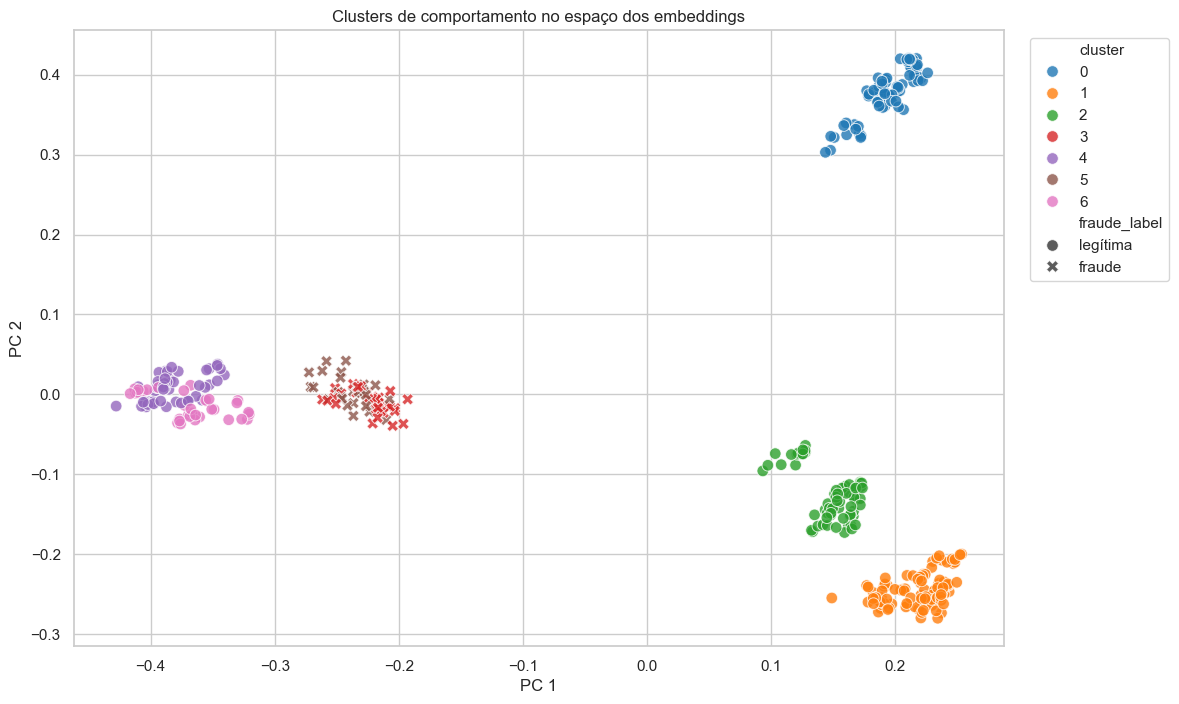

In [26]:
coords = PCA(n_components=2, random_state=42).fit_transform(embeddings)

plot_df = df.assign(
    x=coords[:, 0],
    y=coords[:, 1],
    fraude_label=df["fraude"].map({0: "legítima", 1: "fraude"}),
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="cluster",
    style="fraude_label",
    palette="tab10",
    alpha=0.8,
    s=70,
)
plt.title("Clusters de comportamento no espaço dos embeddings")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


In [27]:
suspicious_clusters = cluster_summary.loc[cluster_summary["fraude_rate"] >= 0.6, "cluster"].tolist()
suspicious_clusters


[3, 5]

In [28]:
suspicious_transactions = (
    df[df["cluster"].isin(suspicious_clusters)]
    .sort_values(["cluster", "valor"], ascending=[True, False])
    [
        [
            "tx_id",
            "cluster",
            "fraude",
            "merchant",
            "descricao",
            "valor",
            "hora",
            "pais",
            "risco_device",
            "narrativa",
        ]
    ]
    .head(20)
)

suspicious_transactions


,tx_id,cluster,fraude,merchant,descricao,valor,hora,pais,risco_device,narrativa
26,tx_1_0029,3,1,CardNow,gift card online em valor alto,804.54,2,US,alto,transação ecommerce no merchant CardNow; descrição gift card online em valor alto; perfil gift_card_madrugada; valor R$ 804.54; hora 02:...
292,tx_1_0009,3,1,CardNow,compra digital de gift card internacional,702.33,2,GB,alto,transação ecommerce no merchant CardNow; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R$ 702.3...
366,tx_1_0053,3,1,CardNow,compra digital de gift card internacional,614.65,4,US,alto,transação ecommerce no merchant CardNow; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R$ 614.6...
64,tx_1_0049,3,1,CardNow,compra digital de gift card internacional,609.94,3,GB,alto,transação ecommerce no merchant CardNow; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R$ 609.9...
402,tx_1_0069,3,1,Voucher Global,compra digital de gift card internacional,571.18,2,GB,alto,transação ecommerce no merchant Voucher Global; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R...
70,tx_1_0051,3,1,GiftFast,gift card online em valor alto,532.55,4,GB,alto,transação ecommerce no merchant GiftFast; descrição gift card online em valor alto; perfil gift_card_madrugada; valor R$ 532.55; hora 04...
223,tx_1_0054,3,1,GiftFast,gift card online em valor alto,499.97,4,GB,alto,transação ecommerce no merchant GiftFast; descrição gift card online em valor alto; perfil gift_card_madrugada; valor R$ 499.97; hora 04...
252,tx_1_0059,3,1,Voucher Global,voucher eletrônico entregue por e-mail,491.04,0,GB,alto,transação ecommerce no merchant Voucher Global; descrição voucher eletrônico entregue por e-mail; perfil gift_card_madrugada; valor R$ 4...
233,tx_1_0062,3,1,Checkout Edge,microtransação para validação de cartão,21.54,4,GB,alto,transação ecommerce no merchant Checkout Edge; descrição microtransação para validação de cartão; perfil micro_teste_cartao; valor R$ 21...
47,tx_1_0055,3,1,Checkout Edge,sequência de compra pequena em gateway,21.52,4,US,alto,transação ecommerce no merchant Checkout Edge; descrição sequência de compra pequena em gateway; perfil micro_teste_cartao; valor R$ 21....


In [29]:
outliers = (
    df.sort_values("distancia_centroide", ascending=False)
    [
        [
            "tx_id",
            "cluster",
            "fraude",
            "merchant",
            "descricao",
            "valor",
            "pais",
            "distancia_centroide",
            "narrativa",
        ]
    ]
    .head(15)
)

outliers


,tx_id,cluster,fraude,merchant,descricao,valor,pais,distancia_centroide,narrativa
252,tx_1_0059,3,1,Voucher Global,voucher eletrônico entregue por e-mail,491.04,GB,0.519964,transação ecommerce no merchant Voucher Global; descrição voucher eletrônico entregue por e-mail; perfil gift_card_madrugada; valor R$ 4...
402,tx_1_0069,3,1,Voucher Global,compra digital de gift card internacional,571.18,GB,0.501295,transação ecommerce no merchant Voucher Global; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R...
223,tx_1_0054,3,1,GiftFast,gift card online em valor alto,499.97,GB,0.494890,transação ecommerce no merchant GiftFast; descrição gift card online em valor alto; perfil gift_card_madrugada; valor R$ 499.97; hora 04...
64,tx_1_0049,3,1,CardNow,compra digital de gift card internacional,609.94,GB,0.487880,transação ecommerce no merchant CardNow; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R$ 609.9...
70,tx_1_0051,3,1,GiftFast,gift card online em valor alto,532.55,GB,0.485408,transação ecommerce no merchant GiftFast; descrição gift card online em valor alto; perfil gift_card_madrugada; valor R$ 532.55; hora 04...
292,tx_1_0009,3,1,CardNow,compra digital de gift card internacional,702.33,GB,0.483330,transação ecommerce no merchant CardNow; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R$ 702.3...
366,tx_1_0053,3,1,CardNow,compra digital de gift card internacional,614.65,US,0.481663,transação ecommerce no merchant CardNow; descrição compra digital de gift card internacional; perfil gift_card_madrugada; valor R$ 614.6...
245,tx_1_0020,5,1,Voucher Global,voucher eletrônico entregue por e-mail,651.79,US,0.480631,transação ecommerce no merchant Voucher Global; descrição voucher eletrônico entregue por e-mail; perfil gift_card_madrugada; valor R$ 6...
261,tx_1_0036,5,1,Voucher Global,voucher eletrônico entregue por e-mail,903.49,US,0.476490,transação ecommerce no merchant Voucher Global; descrição voucher eletrônico entregue por e-mail; perfil gift_card_madrugada; valor R$ 9...
88,tx_1_0066,5,1,CardNow,voucher eletrônico entregue por e-mail,498.01,US,0.468093,transação ecommerce no merchant CardNow; descrição voucher eletrônico entregue por e-mail; perfil gift_card_madrugada; valor R$ 498.01; ...


In [30]:
df["alerta_nao_supervisionado"] = (
    df["cluster"].isin(suspicious_clusters) | (df["percentil_distancia"] >= 0.98)
).astype(int)

print(
    classification_report(
        df["fraude"],
        df["alerta_nao_supervisionado"],
        target_names=["legítima", "fraude"],
        digits=3,
    )
)


              precision    recall  f1-score   support

    legítima      1.000     0.976     0.988       340
      fraude      0.897     1.000     0.946        70

    accuracy                          0.980       410
   macro avg      0.949     0.988     0.967       410
weighted avg      0.982     0.980     0.981       410

